In [ ]:
# Lipi
## Odia Handwritten OCR Project

Lipi is a machine learning project focused on handwritten Odia character recognition.

The goal of this project is to:
- build a structured Odia OCR pipeline
- create and manage custom datasets
- train deep learning models for character recognition
- support regional language AI research

---

## Project Objectives

- Collect handwritten Odia character dataset
- Build preprocessing pipeline
- Train CNN-based OCR models
- Evaluate recognition accuracy
- Build deployable OCR system

# Project Structure

```text
lipi/
│
├── data/
│   ├── raw/
│   ├── processed/
│   ├── samples/
│   └── mini_dataset/
│
├── notebooks/
│   ├── 01_dataset_exploration.ipynb
│   ├── 02_preprocessing.ipynb
│   ├── 03_first_cnn.ipynb
│   ├── 04_full_training.ipynb
│   └── 05_evaluation.ipynb
│
├── src/
│   ├── config/
│   ├── preprocessing/
│   ├── training/
│   ├── evaluation/
│   └── deployment/
│
├── models/
├── outputs/
├── requirements.txt
└── README.md

# Step 1: Install Required Libraries

We install the required Python libraries for:
- image processing
- visualization
- machine learning
- dataset management

In [ ]:
%class_names = list(label_map.keys())

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()pip install pillow matplotlib pandas numpy opencv-python

# Step 2: Import Required Libraries

We import:
- os for file handling
- pandas for dataset indexing
- matplotlib for visualization
- PIL for image processing

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

# Step 3: Mount Google Drive

The handwritten dataset is stored in Google Drive.

Google Drive is used instead of GitHub because:
- image datasets are large
- GitHub is optimized for code
- datasets should remain separate from source code

In [25]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 4: Define Dataset Path

Now we tell Python where our handwritten dataset is stored inside Google Drive.

Our dataset structure looks like this:

```
mini_dataset/
├── CONS_KA/
├── CONS_KHA/
├── CONS_GA/
├── VOW_A/
└── ...
```


Each folder represents one character class.

We will load all images from these folders for training.

In [26]:
# Dataset path inside Google Drive

DATASET_DIR = "/content/drive/MyDrive/lipi/mini_dataset"

print("Dataset Path:", DATASET_DIR)

Dataset Path: /content/drive/MyDrive/lipi/mini_dataset


# Step 5: Verify Dataset Structure

Before training a model, we must verify that:
- folders exist
- images exist
- dataset is readable

This helps catch path mistakes early.

Machine learning debugging is mostly:
"the file path is wrong again."

In [27]:
import os

# List all folders/classes

classes = os.listdir(DATASET_DIR)

print("Total Classes:", len(classes))
print(classes[:10])

Total Classes: 55
['CONS_BA', 'CONS_BHA', 'CONS_CA', 'CONS_CHA', 'CONS_DDA', 'CONS_DA', 'CONS_DDHA', 'CONS_GA', 'CONS_DHA', 'CONS_GHA']


# Step 6: Count Images Per Class

Now we check:
- how many images each character contains
- whether any folders are empty
- whether dataset distribution is balanced

Balanced datasets usually train better.

In [28]:
for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(
        DATASET_DIR,
        folder
    )

    # Skip non-folder files
    if not os.path.isdir(folder_path):
        continue

    image_count = len(os.listdir(folder_path))

    print(f"{folder} → {image_count} images")

CONS_BA → 33 images
CONS_BHA → 29 images
CONS_CA → 43 images
CONS_CHA → 30 images
CONS_DDA → 29 images
CONS_DA → 31 images
CONS_DDHA → 30 images
CONS_GA → 31 images
CONS_DHA → 32 images
CONS_GHA → 29 images
CONS_HA → 28 images
CONS_JA → 29 images
CONS_JHA → 31 images
CONS_KA → 46 images
CONS_KHA → 38 images
CONS_LA → 36 images
CONS_LLA → 29 images
CONS_MA → 28 images
CONS_NGA → 34 images
CONS_NNA → 35 images
CONS_NYA → 30 images
CONS_PA → 29 images
CONS_PHA → 35 images
CONS_NA → 29 images
CONS_SA → 35 images
CONS_RA → 30 images
CONS_SSHA → 29 images
CONS_SHA → 30 images
CONS_TA → 29 images
CONS_THA → 26 images
CONS_TTHA → 34 images
CONS_TTA → 35 images
CONS_YA → 30 images
CONS_YYA → 27 images
DIGIT_0 → 8 images
DIGIT_2 → 8 images
DIGIT_1 → 7 images
DIGIT_3 → 7 images
DIGIT_5 → 8 images
DIGIT_8 → 2 images
DIGIT_6 → 9 images
DIGIT_4 → 7 images
DIGIT_7 → 9 images
DIGIT_9 → 6 images
VOW_AA → 30 images
VOW_A → 39 images
VOW_AU → 32 images
VOW_AI → 33 images
VOW_E → 30 images
VOW_I → 31 imag

# Step 7: Filter Valid Classes

Some folders may contain:
- too few images
- accidental files
- incomplete data

We keep only classes with enough images.

This improves training stability.

In [29]:
MIN_IMAGES = 25

valid_classes = []

for folder in os.listdir(DATASET_DIR):

    folder_path = os.path.join(
        DATASET_DIR,
        folder
    )

    if not os.path.isdir(folder_path):
        continue

    image_count = len(os.listdir(folder_path))

    if image_count >= MIN_IMAGES:

        valid_classes.append(folder)

        print(f"{folder} → {image_count} images")

CONS_BA → 33 images
CONS_BHA → 29 images
CONS_CA → 43 images
CONS_CHA → 30 images
CONS_DDA → 29 images
CONS_DA → 31 images
CONS_DDHA → 30 images
CONS_GA → 31 images
CONS_DHA → 32 images
CONS_GHA → 29 images
CONS_HA → 28 images
CONS_JA → 29 images
CONS_JHA → 31 images
CONS_KA → 46 images
CONS_KHA → 38 images
CONS_LA → 36 images
CONS_LLA → 29 images
CONS_MA → 28 images
CONS_NGA → 34 images
CONS_NNA → 35 images
CONS_NYA → 30 images
CONS_PA → 29 images
CONS_PHA → 35 images
CONS_NA → 29 images
CONS_SA → 35 images
CONS_RA → 30 images
CONS_SSHA → 29 images
CONS_SHA → 30 images
CONS_TA → 29 images
CONS_THA → 26 images
CONS_TTHA → 34 images
CONS_TTA → 35 images
CONS_YA → 30 images
CONS_YYA → 27 images
VOW_AA → 30 images
VOW_A → 39 images
VOW_AU → 32 images
VOW_AI → 33 images
VOW_E → 30 images
VOW_I → 31 images
VOW_II → 34 images
VOW_O → 31 images
VOW_U → 31 images


# Step 8: Sort Class Names

Sorting ensures:
- consistent label ordering
- reproducible training
- easier debugging

Without sorting:
the same class may get different labels later.
Tiny chaos. Huge consequences.

In [30]:
valid_classes.sort()

print(valid_classes)

['CONS_BA', 'CONS_BHA', 'CONS_CA', 'CONS_CHA', 'CONS_DA', 'CONS_DDA', 'CONS_DDHA', 'CONS_DHA', 'CONS_GA', 'CONS_GHA', 'CONS_HA', 'CONS_JA', 'CONS_JHA', 'CONS_KA', 'CONS_KHA', 'CONS_LA', 'CONS_LLA', 'CONS_MA', 'CONS_NA', 'CONS_NGA', 'CONS_NNA', 'CONS_NYA', 'CONS_PA', 'CONS_PHA', 'CONS_RA', 'CONS_SA', 'CONS_SHA', 'CONS_SSHA', 'CONS_TA', 'CONS_THA', 'CONS_TTA', 'CONS_TTHA', 'CONS_YA', 'CONS_YYA', 'VOW_A', 'VOW_AA', 'VOW_AI', 'VOW_AU', 'VOW_E', 'VOW_I', 'VOW_II', 'VOW_O', 'VOW_U']


# Step 9: Create Label Map

Machine learning models do NOT understand:
- "CONS_KA"
- "VOW_A"

They only understand numbers.

So we convert:

CONS_KA → 0
CONS_KHA → 1
CONS_GA → 2

This process is called:
Label Encoding

In [31]:
label_map = {}

for idx, class_name in enumerate(valid_classes):

    label_map[class_name] = idx

print(label_map)

{'CONS_BA': 0, 'CONS_BHA': 1, 'CONS_CA': 2, 'CONS_CHA': 3, 'CONS_DA': 4, 'CONS_DDA': 5, 'CONS_DDHA': 6, 'CONS_DHA': 7, 'CONS_GA': 8, 'CONS_GHA': 9, 'CONS_HA': 10, 'CONS_JA': 11, 'CONS_JHA': 12, 'CONS_KA': 13, 'CONS_KHA': 14, 'CONS_LA': 15, 'CONS_LLA': 16, 'CONS_MA': 17, 'CONS_NA': 18, 'CONS_NGA': 19, 'CONS_NNA': 20, 'CONS_NYA': 21, 'CONS_PA': 22, 'CONS_PHA': 23, 'CONS_RA': 24, 'CONS_SA': 25, 'CONS_SHA': 26, 'CONS_SSHA': 27, 'CONS_TA': 28, 'CONS_THA': 29, 'CONS_TTA': 30, 'CONS_TTHA': 31, 'CONS_YA': 32, 'CONS_YYA': 33, 'VOW_A': 34, 'VOW_AA': 35, 'VOW_AI': 36, 'VOW_AU': 37, 'VOW_E': 38, 'VOW_I': 39, 'VOW_II': 40, 'VOW_O': 41, 'VOW_U': 42}


# Step 10: Load Dataset Images

Now we:
- read every image
- convert to grayscale
- resize to fixed dimensions
- normalize pixel values

Why normalization?

Images normally use:
0 → 255

Neural networks train better with:
0 → 1

In [32]:
images = []
labels = []

IMG_SIZE = 64

loaded_count = 0
failed_count = 0

for class_name in valid_classes:

    class_path = os.path.join(
        DATASET_DIR,
        class_name
    )

    label = label_map[class_name]

    # Read all image files
    for image_name in os.listdir(class_path):

        img_path = os.path.join(
            class_path,
            image_name
        )

        # Read image
        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Skip broken images
        if img is None:
            failed_count += 1
            print("Failed:", img_path)
            continue

        # Resize image
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        # Normalize pixel values
        img = img / 255.0

        # Save image + label
        images.append(img)
        labels.append(label)

        loaded_count += 1

print("Images Loaded :", loaded_count)
print("Images Failed :", failed_count)

Images Loaded : 1370
Images Failed : 0


# Step 11: Convert Dataset to NumPy Arrays

TensorFlow works efficiently with NumPy arrays.

We also reshape images into:
(height, width, channels)

For grayscale:
channels = 1

In [33]:
X = np.array(images)

y = np.array(labels)

# CNN expects:
# (samples, height, width, channels)

X = X.reshape(-1, 64, 64, 1)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1370, 64, 64, 1)
y Shape: (1370,)


# Step 12: One-Hot Encode Labels

Neural networks do not directly use class numbers.

Example:

2

becomes:

[0,0,1,0,0...]

This is called:
One-Hot Encoding

Required for multi-class classification.

In [34]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(y)

print("Encoded y Shape:", y.shape)

Encoded y Shape: (1370, 43)


# Step 13: Split Training and Testing Data

We split dataset into:
- training data
- testing data

Training data:
used to learn patterns

Testing data:
used to evaluate model performance

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (1096, 64, 64, 1)
Testing Shape : (274, 64, 64, 1)


# Step 14: Visualize Random Samples

Before training:
ALWAYS inspect the dataset visually.

This helps detect:
- bad crops
- wrong labels
- broken images
- empty images

Bad data destroys model quality.

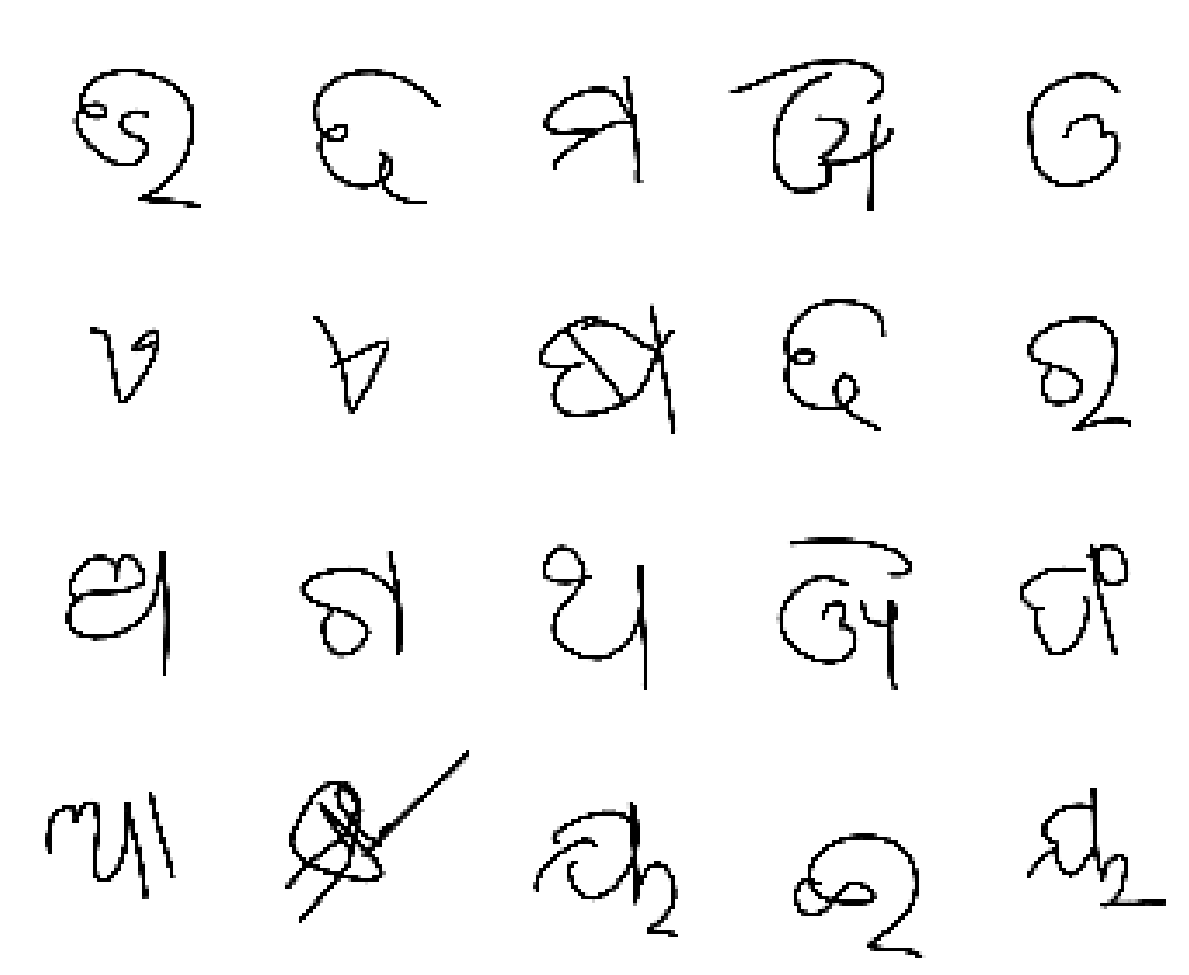

In [36]:
import random

plt.figure(figsize=(12, 10))

for i in range(20):

    idx = random.randint(0, len(X_train) - 1)

    plt.subplot(4, 5, i + 1)

    plt.imshow(
        X_train[idx].reshape(64, 64),
        cmap="gray"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Dataset Preparation Complete

At this stage we have successfully:
- mounted Google Drive
- loaded dataset
- encoded labels
- normalized images
- prepared training/testing data

Next step:
Build and train the first CNN model.

Now the actual machine learning begins.
The preprocessing pipeline was the real war.
The neural network arrives later to collect applause.

# Step 13: Build First CNN Model

We now build our first Convolutional Neural Network (CNN).

CNNs are specialized neural networks designed for image processing.

The model will learn:
- edges
- curves
- shapes
- handwriting patterns

This is the first actual OCR learning stage of the project.

Input:
64 × 64 grayscale character image

Output:
predicted Odia character class

In [39]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [41]:
num_classes = len(valid_classes)

print("Number of Classes:", num_classes)

Number of Classes: 43


# CNN Architecture

Our CNN contains:

- Convolution layers for feature extraction
- MaxPooling for dimensionality reduction
- Dense layers for classification
- Dropout for overfitting prevention

Architecture:

Input Image
→ Conv Layer
→ Pooling
→ Conv Layer
→ Pooling
→ Flatten
→ Dense
→ Output

In [42]:
model = Sequential([

    # Input layer
    Input(shape=(64, 64, 1)),

    # First convolution block
    Conv2D(
        32,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    # Second convolution block
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D((2, 2)),


    # Flatten feature maps
    Flatten(),


    # Dense layer
    Dense(
        128,
        activation='relu'
    ),

    # Regularization
    Dropout(0.3),


    # Output layer
    Dense(
        num_classes,
        activation='softmax'
    )
])

# Step 14: Compile Model

Compiling defines:

- optimizer
- loss function
- evaluation metric

We use:

Optimizer:
Adam

Loss:
categorical_crossentropy

Metric:
accuracy

In [45]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 15: Train CNN Model

The model now learns patterns from handwritten Odia characters.

Training Process:
- forward propagation
- loss calculation
- backpropagation
- weight optimization

Epoch:
one complete pass through the dataset

In [46]:
history = model.fit(

    X_train,
    y_train,

    epochs=10,

    validation_data=(
        X_test,
        y_test
    )

)

Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.0301 - loss: 3.8139 - val_accuracy: 0.0182 - val_loss: 3.7546
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.0721 - loss: 3.6463 - val_accuracy: 0.1204 - val_loss: 3.4735
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.1852 - loss: 3.1088 - val_accuracy: 0.2737 - val_loss: 2.8552
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.3422 - loss: 2.4503 - val_accuracy: 0.3978 - val_loss: 2.5112
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - accuracy: 0.4553 - loss: 1.9964 - val_accuracy: 0.4708 - val_loss: 2.2521
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.5474 - loss: 1.6645 - val_accuracy: 0.4781 - val_loss: 2.1348
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.6086 - loss: 1.3734 - val_accuracy: 0.5000 - val_loss: 2.0144
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.6807 - loss: 1.0923 - val_accuracy: 0.

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,890,371 (18.66 MB)

 Trainable params: 1,630,123 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,260,248 (12.44 MB)

# Step 16: Save Trained Model

We save the trained OCR model for:
- future predictions
- evaluation
- deployment
- inference testing

In [49]:
model.save(
    "/content/drive/MyDrive/lipi_models/odia_ocr_cnn.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


# Step 17: Visualize Training Performance

We plot:
- training accuracy
- validation accuracy
- training loss
- validation loss

This helps analyze model behavior.

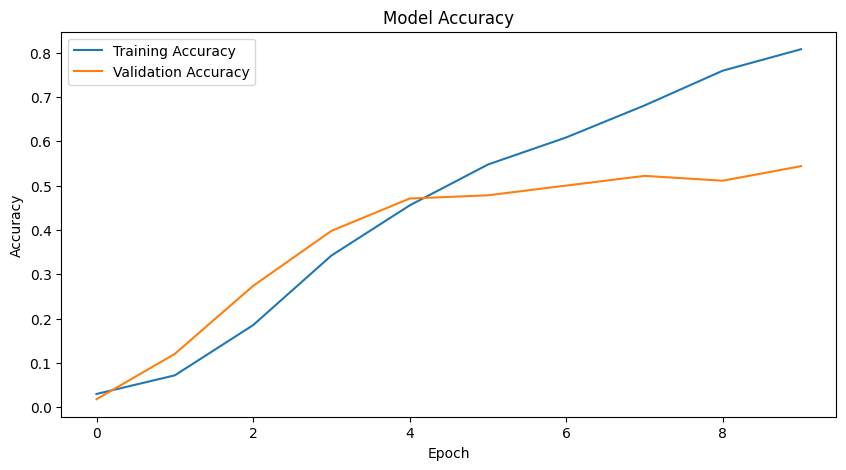

In [50]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

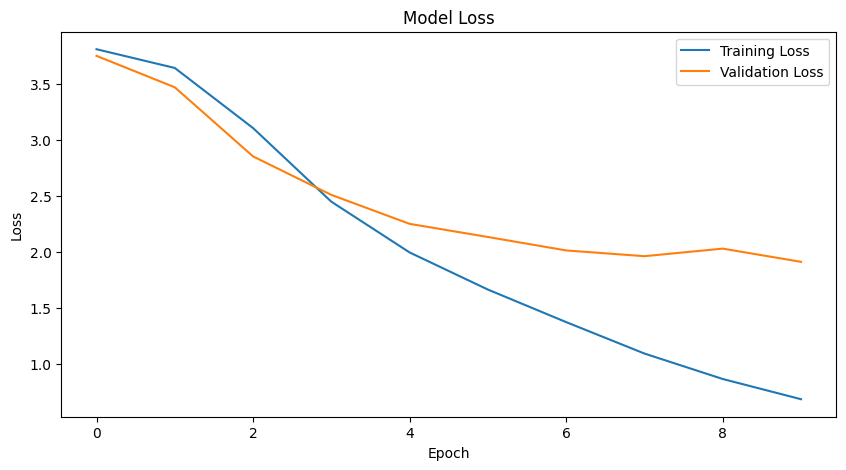

In [51]:
# Loss Plot
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Step 18: Evaluation Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test)

# Convert one-hot encoded labels to class indices
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Evaluation Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Detailed report
print("\nClassification Report")
print(classification_report(y_true, y_pred))

# Step 19: Confusion Matix

In [ ]:
class_names = list(label_map.keys())

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Step 20: Test Random Prediction

We now test the OCR model on unseen handwritten images.

The model predicts:
which Odia character the image belongs to.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


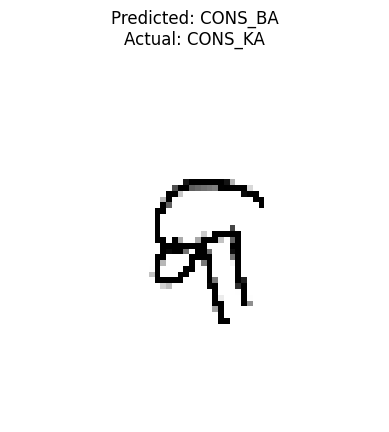

In [127]:
import random
import numpy as np

# Pick random test image
idx = random.randint(0, len(X_test) - 1)

sample = X_test[idx]

# Predict
prediction = model.predict(
    sample.reshape(1, 64, 64, 1)
)

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_test[idx])

# Reverse label map
reverse_label_map = {
    v: k for k, v in label_map.items()
}

predicted_label = reverse_label_map[predicted_class]

actual_label = reverse_label_map[actual_class]

# Display image
plt.imshow(
    sample.reshape(64, 64),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_label}\nActual: {actual_label}"
)

plt.axis("off")

plt.show()